# **Klasifikasi Jenis Kelamin Penguin | K-Means Clustering**

Model klasifikasi jenis kelamin penguin menggunakan algoritma K-Means Clustering

## 1. Data Preparation

### 1.1 Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import messagebox

### 1.2 Read Dataset

In [2]:
df = pd.read_csv('penguins.csv')

In [3]:
# 5 baris teratas
print('5 baris teratas:')
df.head()

5 baris teratas:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
# 10 baris acak
print('10 baris acak:')
df.sample(10)

10 baris acak:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
100,35.0,17.9,192.0,3725.0,FEMALE
288,43.5,14.2,220.0,4700.0,FEMALE
68,35.9,16.6,190.0,3050.0,FEMALE
64,36.4,17.1,184.0,2850.0,FEMALE
304,44.9,13.8,212.0,4750.0,FEMALE
310,47.5,15.0,218.0,4950.0,FEMALE
69,41.8,19.4,198.0,4450.0,MALE
252,45.1,14.5,207.0,5050.0,FEMALE
213,46.8,16.5,189.0,3650.0,FEMALE
120,36.2,17.2,187.0,3150.0,FEMALE


In [5]:
# Ringkasan informasi
print('Ringkasan informasi dataset:\n')
df.info()

Ringkasan informasi dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [6]:
# Ringkasan statistik
print('Ringkasan statistik dataset:\n')
df.describe()

Ringkasan statistik dataset:



,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


### 1.3 Missing Value

#### 1.3.1 Cek Missing Value

In [7]:
# Total missing value
print('Total missing value:', df.isnull().sum().sum())

Total missing value: 17


In [8]:
# jumlah missing value setiap fitur
print('Jumlah missing value setiap fitur:\n') 
df.isnull().sum()

Jumlah missing value setiap fitur:



culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [9]:
df['sex'].value_counts()

sex
MALE      169
FEMALE    165
.           1
Name: count, dtype: int64

In [10]:
df['sex'] = df['sex'].replace('.', 'MALE')


In [11]:
df['sex'].unique()

array(['MALE', 'FEMALE', nan], dtype=object)

In [12]:
df['sex'].value_counts(dropna=False)




sex
MALE      170
FEMALE    165
NaN         9
Name: count, dtype: int64

#### 1.3.2 Penanganan Missing Value

In [13]:
# Menangani missing value pada kolom numerik dengan median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [14]:
# Menangani missing value pada kolom object dengan modus
num_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [15]:
print('Jumlah nilai kosong setelah ditangani:', df.isnull().sum().sum())

Jumlah nilai kosong setelah ditangani: 0


### 1.4 Data Duplikat

In [16]:
# Total data duplikat
print('Total data duplikat:', df.duplicated().sum())

Total data duplikat: 1


In [17]:
df[df.duplicated(keep=False)]

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,44.45,17.3,197.0,4050.0,MALE
339,44.45,17.3,197.0,4050.0,MALE


In [18]:
# Menangani nilai duplikat
df = df.drop_duplicates(keep='first')



In [19]:
print('Total data duplikat setelah ditangani:', df.duplicated().sum())


Total data duplikat setelah ditangani: 0


### 1.5 Encoding 

Kami encoding mengunakan teknik mapping, dengan:
- 0 -> Penguin Betina
- 1 -> Penguin Jantan

In [20]:
# Encoding fitur 'sex'
df['sex'] = df['sex'].map({
    'MALE' : 1,
    'FEMALE' : 0,
})

In [21]:
df.dtypes

culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                    int64
dtype: object

## 2. Exploratory Data Analysis

### 2.1 Distriibusi Data

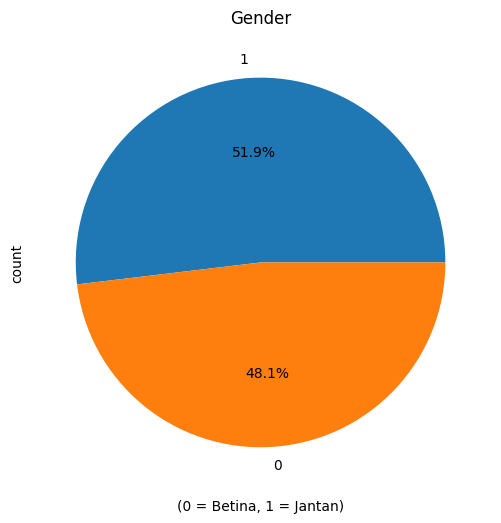

In [22]:
# Grafik Pie
plt.figure(figsize=(8,6))
df['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender')
plt.xlabel('(0 = Betina, 1 = Jantan)')
plt.show()


### 2.2 Outlier

#### 2.2.1 Cek Outlier

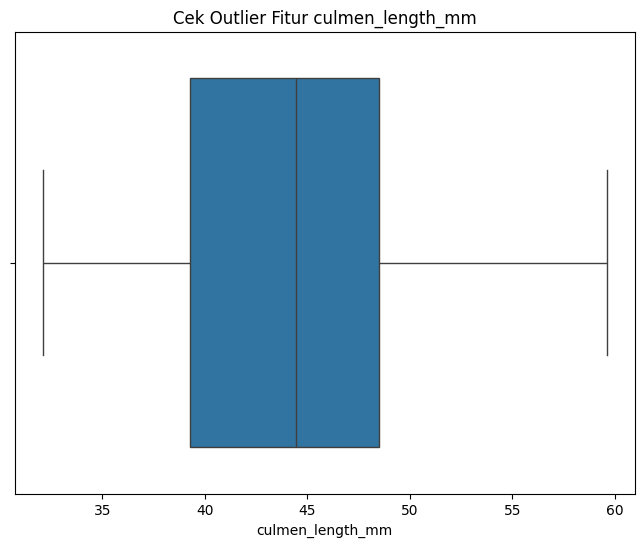

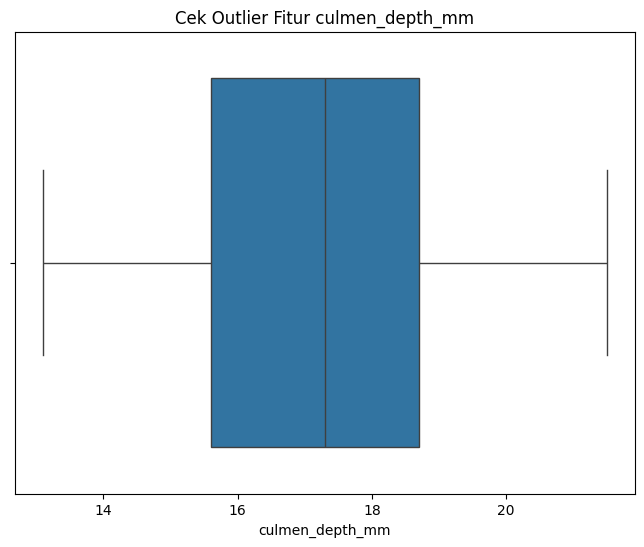

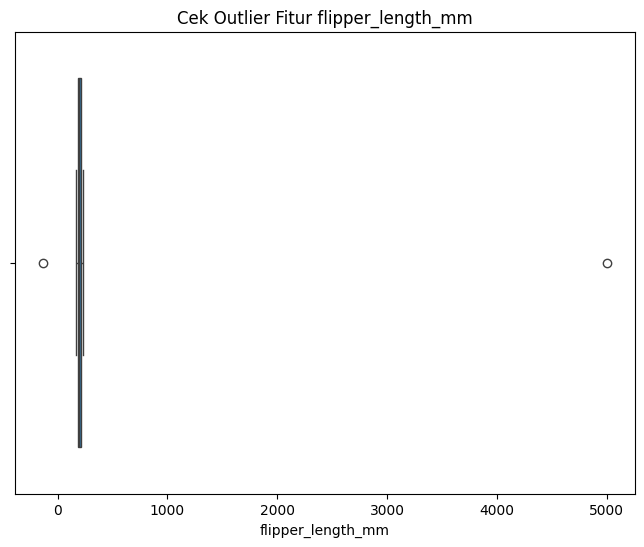

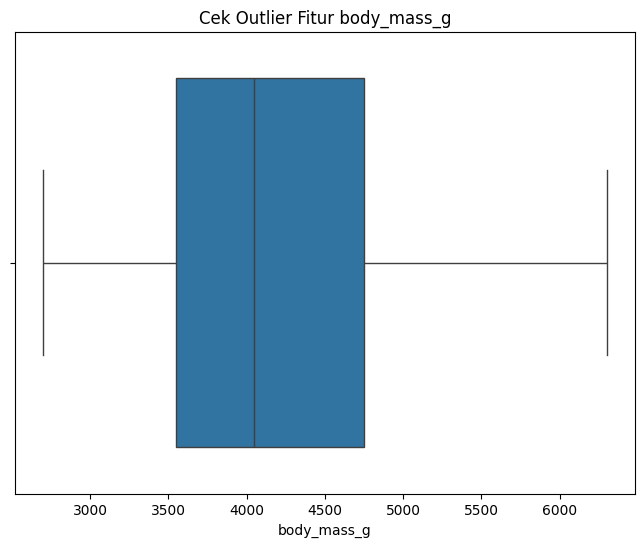

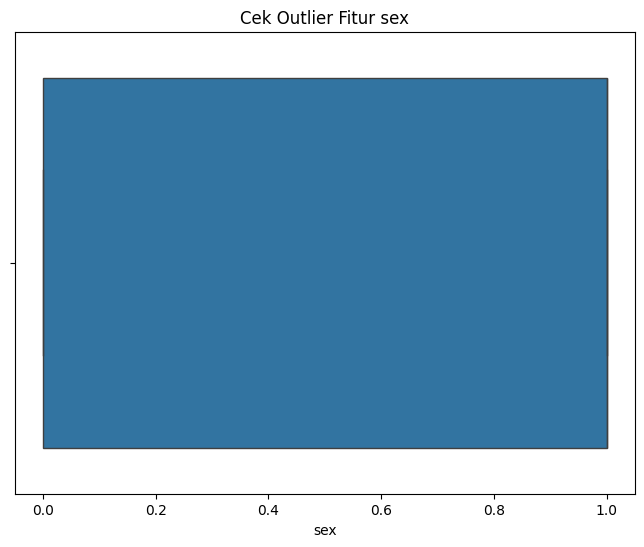

In [23]:
idx = 0
for col in df.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'Cek Outlier Fitur {df.columns[idx]}')
    idx += 1
    plt.show()


#### 2.2.2 Penanganan Outlier

In [24]:

# Perulangan untuk cek outlier masing - masing kolom
for col in df.columns:

    # Menentukan kuartil atas dan bawah
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
     
    # Menghitung interquartil
    IQR = Q3 - Q1 

    # Menentukan batas atas dan bawah
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    # Menghitung jumlah outlier
    outlier = (df[col] < batas_bawah) | (df[col] > batas_atas)
    outlier_count = outlier.sum()

    print(f"Kolom = {col}") 
    print(f'Jumlah outlier = {outlier_count}\n')

    # Mengubah outlier menjadi median
    median_fix = df[col].median()

    df.loc[outlier, col] = median_fix
    

Kolom = culmen_length_mm
Jumlah outlier = 0

Kolom = culmen_depth_mm
Jumlah outlier = 0

Kolom = flipper_length_mm
Jumlah outlier = 2

Kolom = body_mass_g
Jumlah outlier = 0

Kolom = sex
Jumlah outlier = 0



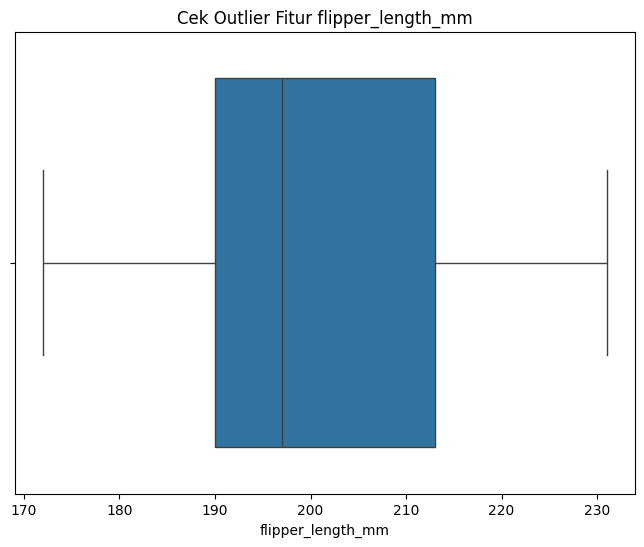

In [25]:
# Cek ulang outlier
plt.figure(figsize=(8,6))
sns.boxplot(x=df['flipper_length_mm'])
plt.title(f'Cek Outlier Fitur flipper_length_mm')
plt.show()

## 3. Model

In [26]:
X = df.drop('sex', axis=1).values

### 3.2 Feature Scalling

In [28]:
# Standarisasi
data_df = df.values
mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1e-9
X_scaled = (X - mean) / std

### 3.3 Fungsi K-Means dan SSE

In [29]:
def hitung_kmeans(data, k, max_iter=100):
    idx = np.random.choice(len(data), k, replace=False)
    centroids = data[idx]
    
    for _ in range(max_iter):
        dist = np.sqrt(((data - centroids[:, np.newaxis])**2).sum(axis=2))
        labels = np.argmin(dist, axis=0)
        
        new_centroids = np.array([data[labels == i].mean(axis=0) if len(data[labels == i]) > 0 
                                  else centroids[i] for i in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
        
    sse = 0
    for i in range(k):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i])**2)
    return centroids, labels, sse


### 3.4 Visualisasi SSE

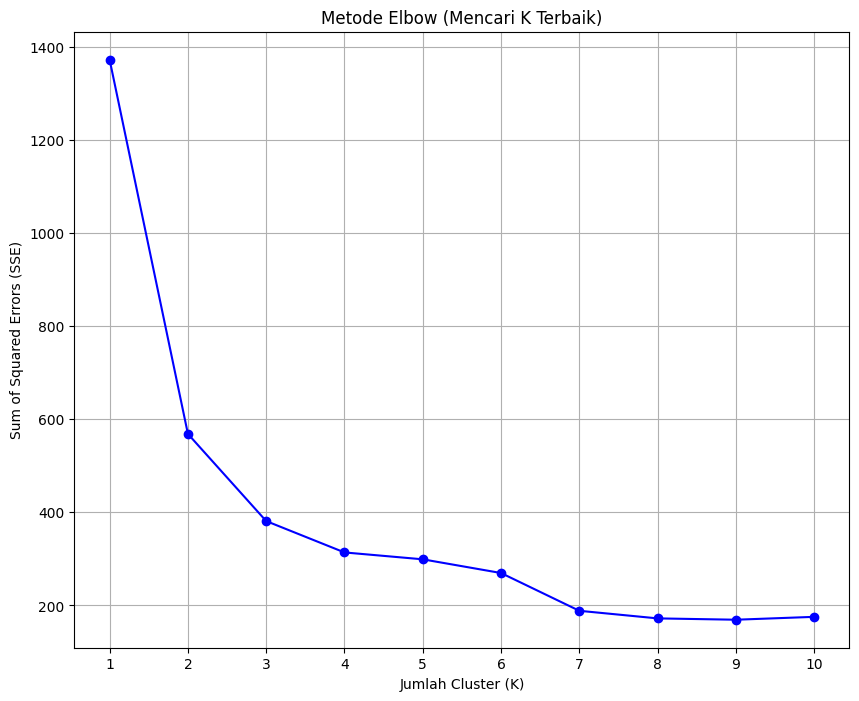

In [30]:
sse_list = []
ks = range(1, 11)
for k in ks:
    _, _, sse_val = hitung_kmeans(X_scaled, k)
    sse_list.append(sse_val)

plt.figure(figsize=(10, 8))
plt.plot(ks, sse_list, 'bo-')
plt.title('Metode Elbow (Mencari K Terbaik)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.xticks(range(1,11))
plt.show() # Jendela ini akan muncul sendiri

## 4. Evaluasi 

In [31]:
def hitung_silhouette(data, labels, centroids):
    n = len(data)
    if len(np.unique(labels)) < 2: return 0
    
    silhouette_vals = []
    for i in range(n):
        same_cluster = data[labels == labels[i]]
        if len(same_cluster) > 1:
            a_i = np.mean(np.linalg.norm(same_cluster - data[i], axis=1))
        else:
            a_i = 0
            
        b_i = float('inf')
        for k in range(len(centroids)):
            if k == labels[i]: continue
            other_cluster = data[labels == k]
            if len(other_cluster) > 0:
                dist_other = np.mean(np.linalg.norm(other_cluster - data[i], axis=1))
                b_i = min(b_i, dist_other)
        
        s_i = (b_i - a_i) / max(a_i, b_i)
        silhouette_vals.append(s_i)
        
    return np.mean(silhouette_vals)


In [32]:
sse_list = []
silhouette_list = []
ks = range(1, 11)

for k in ks:
    centroids, labels, sse_val = hitung_kmeans(X_scaled, k)
    sse_list.append(sse_val)
    
    sil_score = hitung_silhouette(X_scaled, labels, centroids)
    silhouette_list.append(sil_score)

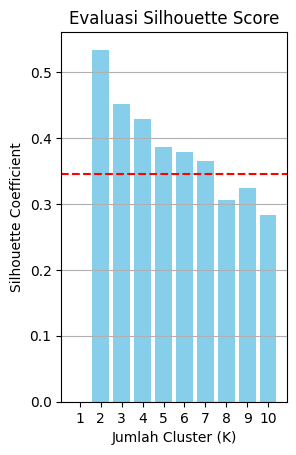

In [33]:
plt.subplot(1, 2, 2)
plt.Figure(figsize=(16,10))
plt.bar(ks, silhouette_list, color='skyblue')
plt.axhline(y=np.mean(silhouette_list), color='red', linestyle='--')
plt.title('Evaluasi Silhouette Score')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Coefficient')
plt.grid(axis='y')
plt.xticks(range(1,11))
plt.show()

In [34]:
klom = df.drop('sex', axis=1)
fitur_klom = klom.columns
skilled = pd.DataFrame(X_scaled, columns=fitur_klom)

print(skilled.head(10))

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
0         -0.886062         0.786370          -1.421713    -0.564383
1         -0.812582         0.126151          -1.064881    -0.501856
2         -0.665624         0.430867          -0.422582    -1.189653
3          0.096723         0.075365          -0.279848    -0.189222
4         -1.326937         1.091086          -0.565315    -0.939545
5         -0.849322         1.751305          -0.779414    -0.689437
6         -0.922801         0.329295          -1.421713    -0.720701
7         -0.867692         1.243444          -0.422582     0.592366
8         -1.804552         0.481653          -0.565315    -0.908282
9         -0.353337         1.548161          -0.279848     0.060886


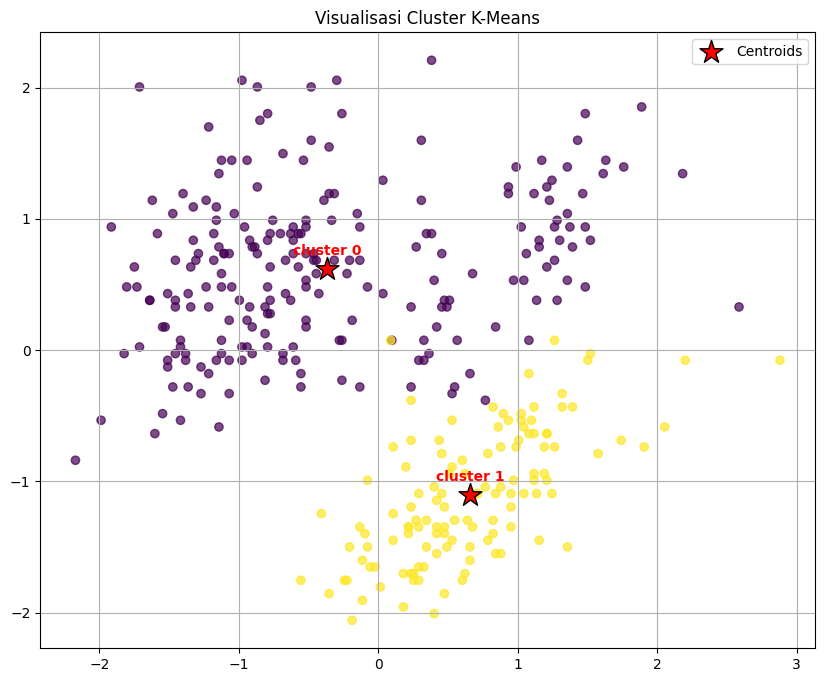

In [35]:
centroids, labels, sse = hitung_kmeans(X_scaled, k=2)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='*', s=300, edgecolor='black', label='Centroids')

for i, txt in enumerate(range(len(centroids))):
    plt.annotate(f"cluster {txt}", (centroids[i,0], centroids[i,1]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold', color='red')

plt.title('Visualisasi Cluster K-Means')
plt.legend()
plt.grid(True)
plt.show()

## 5. GUI

In [ ]:
final_centroids, _, _ = hitung_kmeans(X_scaled, k=2)

def prediksi():
    try:
        user_data = np.array([
            float(entry_l.get()), 
            float(entry_d.get()),
            float(entry_f.get()), 
            float(entry_m.get())
        ])
        
        user_scaled = (user_data - mean) / std
        
        distances = np.sqrt(((user_scaled - final_centroids)**2).sum(axis=1))
        cluster = np.argmin(distances)
        
        hasil = f"Masuk ke Cluster: {cluster}"
        lbl_hasil.config(text=hasil, fg="green")
        messagebox.showinfo("Sukses", f"Prediksi Selesai: {cluster}")
        
    except ValueError:
        messagebox.showerror("Error", "Masukkan format angka yang benar!")

root = tk.Tk()
root.title("Penguin Sex Prediction")
root.geometry("300x400")

tk.Label(root, text="Klasifikasi Penguin", font=("Arial", 12, "bold")).pack(pady=10)

fields = ["Culmen Length", "Culmen Depth", "Flipper Length", "Body Mass"]
entries = []

for f in fields:
    tk.Label(root, text=f).pack()
    e = tk.Entry(root, justify='center')
    e.pack(pady=5)
    entries.append(e)

entry_l, entry_d, entry_f, entry_m = entries

btn = tk.Button(root, text="Prediksi", command=prediksi, bg="green")
btn.pack(pady=20)

lbl_hasil = tk.Label(root, text="", font=("Arial", 10, "bold"))
lbl_hasil.pack()

root.mainloop()